# Seminar 01: Distances between Distributions

In this notebook, we explore:

1. KL Divergence
2. JS Divergence
3. MSE-based "distribution mismatch" as a naive alternative
4. Pitfalls of these metrics when the target distribution is multimodal
5. How these divergences can be optimized in a simple Torch framework

In [7]:
import matplotlib.pyplot as plt
from matplotlib import style
style.use('fivethirtyeight')
%matplotlib inline

import numpy as np

import torch
from torch import distributions as distrs

from IPython.display import clear_output

## Helper Functions

In [8]:
def plot_2d_dots(dots, color=None, label='None', xlim=(-10, 10), ylim=(-10, 10), cmap='viridis'):
    """
    Plots 2D points in a scatter plot.
    
    Args:
        dots (torch.Tensor or np.ndarray): shape (N, 2)
        color: color or array-like of color values
        label (str): label for the points
        xlim, ylim (tuple): x and y plot limits
    """
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.scatter(dots[:, 0], dots[:, 1], s=1, c=color, label=label, cmap=cmap)

In [9]:
def get_parameters(mu=0., sigma=1., requires_grad=True):
    """
    Creates trainable parameters for:
      - Mean vector in R^2
      - Lower-triangular L with shape (2,2),
          L = [[l11,  0. ],
               [l21, l22]]
        so that covariance = L * L^T is always positive definite.
    
    Returns:
      train_mu: torch.Tensor, shape (2,)
      raw_l11, raw_l22, raw_l21: torch.Tensors (scalars)
    """
    train_mu = torch.tensor([mu, mu], dtype=torch.float32, requires_grad=requires_grad)

    # We'll store L's diagonal in log-space so they remain >0
    raw_l11 = torch.tensor(np.log(sigma), dtype=torch.float32, requires_grad=requires_grad)
    raw_l22 = torch.tensor(np.log(sigma), dtype=torch.float32, requires_grad=requires_grad)

    # Off-diagonal can be unconstrained
    raw_l21 = torch.tensor(0.0, dtype=torch.float32, requires_grad=requires_grad)

    return train_mu, raw_l11, raw_l21, raw_l22

def create_distr(mu, raw_l11, raw_l21, raw_l22):
    """
    Builds a 2D MultivariateNormal with covariance = L @ L.T,
    where L is lower-triangular with trainable parameters.
    """
    # Exponentiate diagonals so they remain > 0
    l11 = torch.exp(raw_l11)
    l22 = torch.exp(raw_l22)

    # Create an empty 2x2 tensor on the same device (and same dtype)
    L = torch.zeros(2, 2, dtype=torch.float32, device=mu.device)
    
    # Now fill in the lower-triangular entries in-place.
    # This preserves the gradient relationship to raw_lXX
    L[0, 0] = l11      # diagonal (row=0, col=0)
    L[1, 0] = raw_l21  # below diagonal (row=1, col=0)
    L[1, 1] = l22      # diagonal (row=1, col=1)
    # The upper-right entry (L[0,1]) remains zero, which is standard for lower-tri.

    # Now covariance = L @ L^T is guaranteed positive-definite
    cov = L @ L.T

    return distrs.MultivariateNormal(mu, cov)

def sample(distr, num_samples):
    """
    Draw samples from a given Torch distribution.
    
    Args:
        distr (torch.distributions.Distribution)
        num_samples (int)
    
    Returns:
        torch.Tensor of shape (num_samples, 2)
    """
    return distr.sample(torch.Size([num_samples]))

## 1. Toy Example with a Single Gaussian Target

### Target Distribution $P$ Initialization

In [10]:
# Define a target distribution: 2D Gaussian with center at (-5, -5)
train_mu, raw_l11, raw_l21, raw_l22 = get_parameters(mu=-5., sigma=1., requires_grad=False)
target = create_distr(train_mu, raw_l11, raw_l21, raw_l22)

# Draw samples from the target
x = sample(target, 1000)
# Probability for each sample under the target distribution, px = p(x)
px = target.log_prob(x).exp()

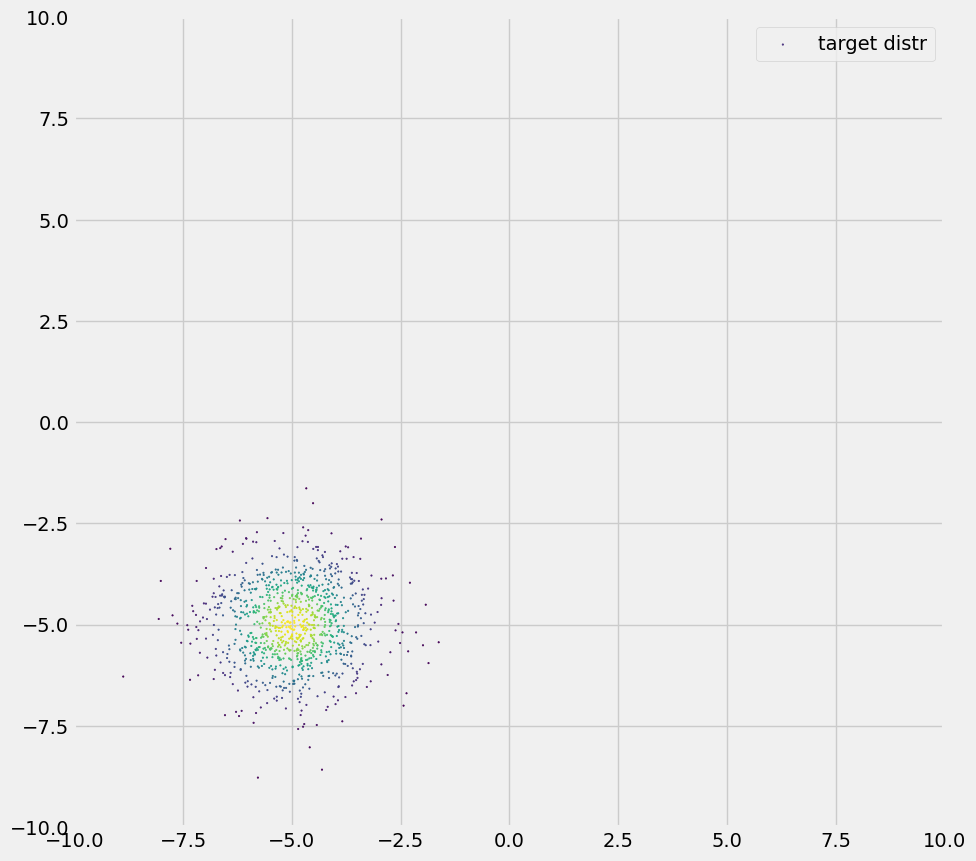

In [11]:
plt.figure(figsize=(10, 10))
plot_2d_dots(x, color=px, label='target distr')
plt.legend()
plt.show()

### Parameterized Distribution $Q$ Initialization

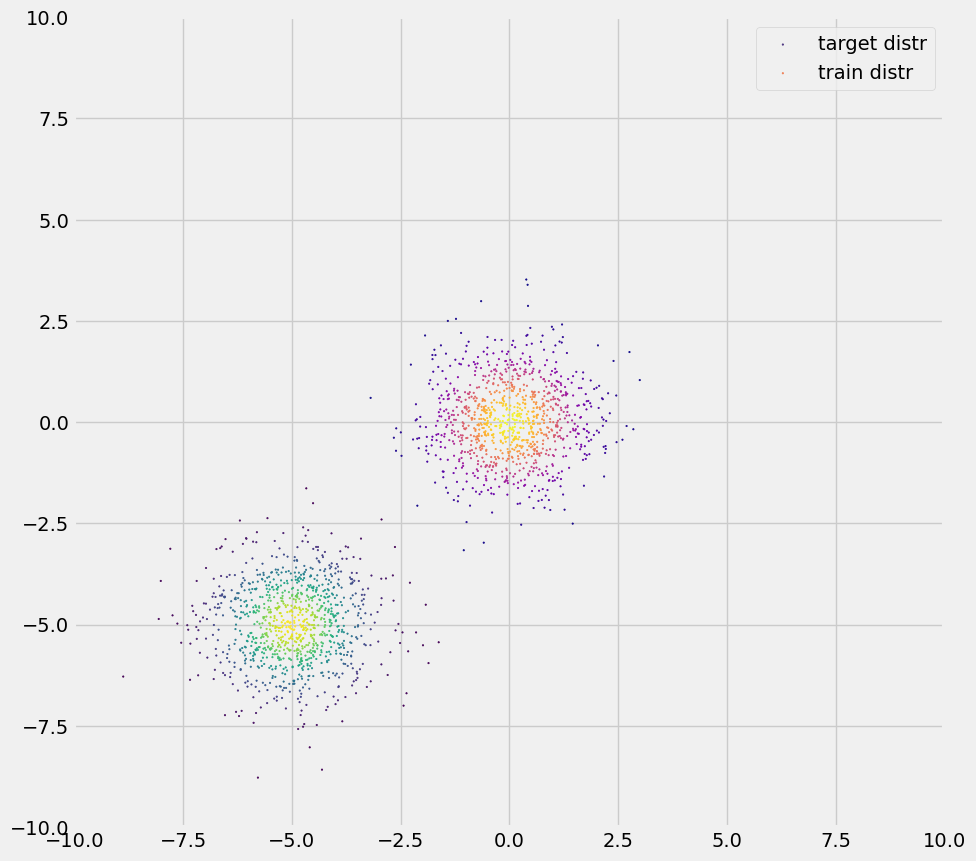

In [12]:
# Create a parameterized distribution Q, with trainable mu and sigma
train_mu, raw_l11, raw_l21, raw_l22 = get_parameters()
Q = create_distr(train_mu, raw_l11, raw_l21, raw_l22)

# Draw samples from the parameterized distribution Q
q_sample = sample(Q, 1000)

# Plot
plt.figure(figsize=(10, 10))
plot_2d_dots(x, color=px, label='target distr')
plot_2d_dots(q_sample, color=Q.log_prob(q_sample).exp().detach(), label='train distr', cmap='plasma')
plt.legend()
plt.show()

### KL Divergence

$$
\text{KL}(P || Q) = \int p(x) \log \left[ \frac{p(x)}{q(x)} \right] dx
$$

We estimate it via samples from $P$:
$$
\text{KL}(P || Q) \approx \frac{1}{N} \sum_{x_i \sim P} \left[ \log p(x_i) - \log q(x_i) \right]
$$

In [13]:
def kl_loss(px, qx, weights=None):
    """
    Approximate KL divergence KL(P || Q) using samples x_i ~ P:
    
    KL(P || Q) ~ mean_over_i [ log(px_i) - log(qx_i) ]
    
    Args:
        px: p(x_i), shape (N,)
        qx: q(x_i), shape (N,)
        weights: object weights (when importance sampling is used)
    Returns:
        A scalar (torch.Tensor) representing the approximate KL.
    """
    if weights is None: 
        weights = torch.ones_like(px)
    
    return torch.mean(weights * (px.log2() - qx.log2()))

### Fitting $Q$ to $P$ with KL

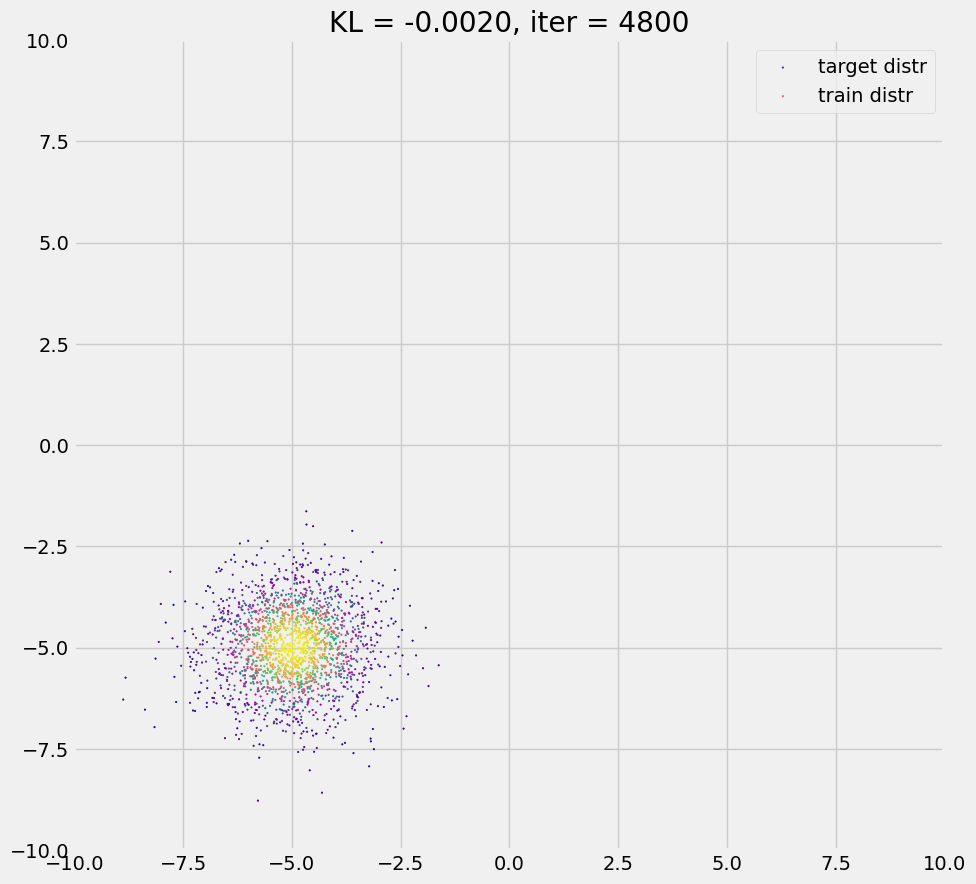

In [14]:
# Re-initialize trainable parameters
train_mu, raw_l11, raw_l21, raw_l22 = get_parameters()
optimizer = torch.optim.Adam([train_mu, raw_l11, raw_l21, raw_l22], lr=0.1)

num_iterations = 5000
for i in range(num_iterations):
    optimizer.zero_grad()
    Q = create_distr(train_mu, raw_l11, raw_l21, raw_l22)
    qx = Q.log_prob(x).exp()
    
    loss = kl_loss(px, qx)
    
    loss.backward()
    optimizer.step()
    
    if i % 200 == 0:
        clear_output(True)
        plt.figure(figsize=(10, 10))
        plt.title(f'KL = {loss.item():.4f}, iter = {i}')
        plot_2d_dots(x, color=px, label='target distr')
        
        # Plot some samples from Q
        q_sample = sample(Q, 1000)
        plot_2d_dots(q_sample, color=Q.log_prob(q_sample).exp().detach(), label='train distr', cmap='plasma')   
        plt.legend()
        plt.show()

## 2. Multimodal Target Example

We define a target distribution P as mixture of two Gaussians.

In [15]:
target1 = create_distr(*get_parameters(mu=-5., sigma=1., requires_grad=False))
target2 = create_distr(*get_parameters(mu=4., sigma=1., requires_grad=False))

def sample_from_mixture(n_samples):
    half = n_samples // 2
    x1 = sample(target1, half)
    x2 = sample(target2, n_samples - half)
    return torch.cat([x1, x2], dim=0)

def log_prob_mixture(x):
    log_p1 = target1.log_prob(x)
    log_p2 = target2.log_prob(x)
    
    half_log = np.log(0.5)
    return torch.logaddexp(log_p1 + half_log, log_p2 + half_log)

class MixtureTarget:
    def sample(self, shape=torch.Size([])):
        if len(shape) == 0:
            shape = (1,)
        n = shape[0]
        return sample_from_mixture(n)

    def log_prob(self, x):
        return log_prob_mixture(x)

target = MixtureTarget()
x = target.sample((2000,))
px = target.log_prob(x).exp()

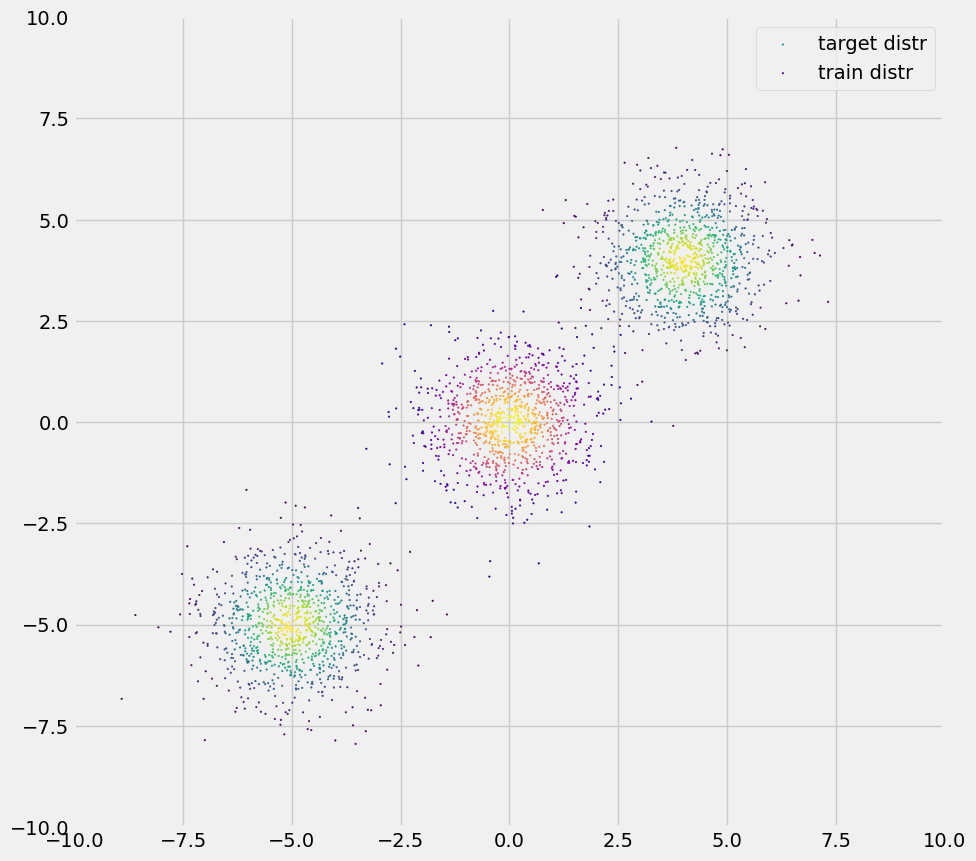

In [16]:
# Visualize Q vs the mixture
train_mu, raw_l11, raw_l21, raw_l22 = get_parameters()
Q = create_distr(train_mu, raw_l11, raw_l21, raw_l22)
q_sample = sample(Q, 1000)

plt.figure(figsize=(10, 10))
plot_2d_dots(x, color=px, label='target distr')
plot_2d_dots(q_sample, color=Q.log_prob(q_sample).exp().detach(), label='train distr', cmap='plasma')
plt.legend()
plt.show()

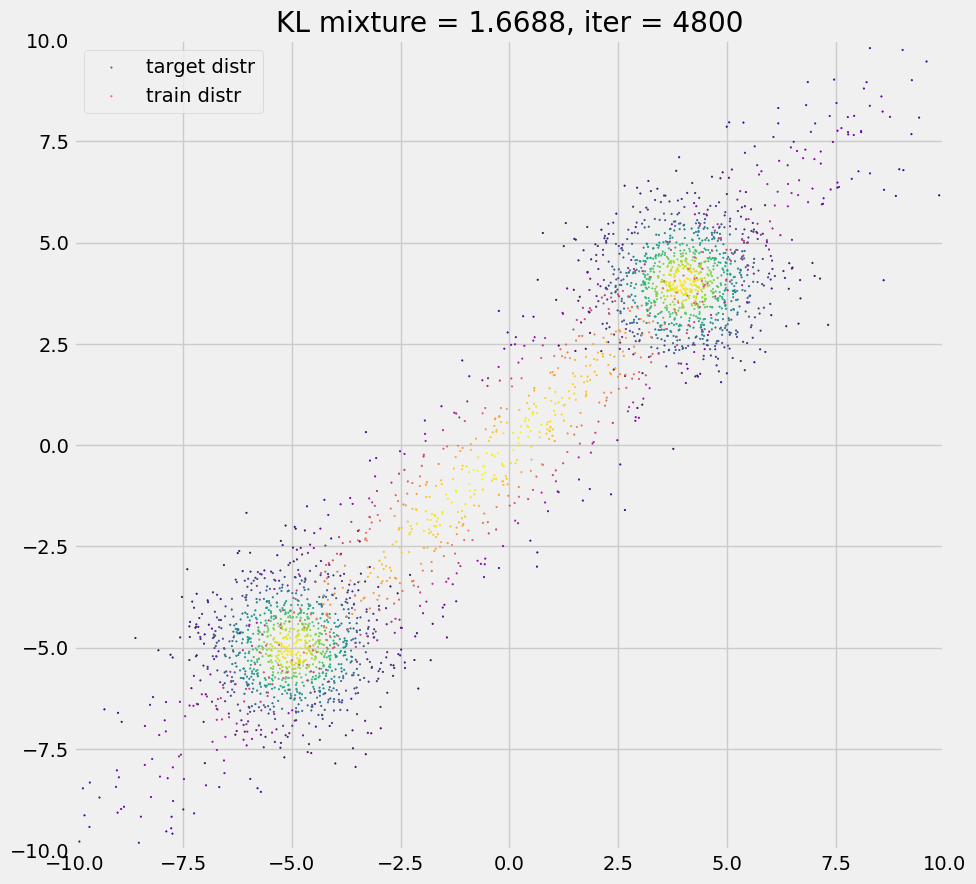

In [17]:
# Let's see if KL training helps
optimizer = torch.optim.Adam([train_mu, raw_l11, raw_l21, raw_l22], lr=0.1)

for i in range(5000):
    optimizer.zero_grad()
    Q = create_distr(train_mu, raw_l11, raw_l21, raw_l22)
    qx = Q.log_prob(x).exp()
    
    loss = kl_loss(px, qx)
    loss.backward()
    optimizer.step()
    
    if i % 200 == 0:
        clear_output(True)
        plt.figure(figsize=(10, 10))
        plt.title(f'KL mixture = {loss.item():.4f}, iter = {i}')
        plot_2d_dots(x, color=px, label='target distr')
        q_sample = sample(Q, 1000)
        plot_2d_dots(q_sample, color=Q.log_prob(q_sample).exp().detach(), label='train distr', cmap='plasma')
        plt.legend()
        plt.show()

## 3. Jensen-Shannon Divergence

$$
\text{JS}(P || Q) = \frac{1}{2} \left[\text{KL}(P || M) + \text{KL}(Q || M)\right]
$$
where $M = \frac{1}{2} (P + Q)$.

To approximate the JS divergence using Monte Carlo sampling:

1. Draw $N$ samples $\{x_i\}_{i=1}^N$ from distribution $P$.
2. Draw $N$ samples $\{y_j\}_{j=1}^N$ from distribution $Q$.

The ЛД divergence terms are approximated as:

$$
\text{KL}(P || M) \approx \frac{1}{N} \sum_{i=1}^N \log \frac{P(x_i)}{M(x_i)}, \quad x_i \sim P
$$

$$
\text{KL}(Q || M) \approx \frac{1}{N} \sum_{j=1}^N \log \frac{Q(y_j)}{M(y_j)}, \quad y_j \sim Q
$$

Finally, the Jensen-Shannon Divergence is estimated as:

$$
\text{JS}(P || Q) \approx \frac{1}{2N} \left[ \sum_{i=1}^N \log \frac{P(x_i)}{M(x_i)} + \sum_{j=1}^N \log \frac{Q(y_j)}{M(y_j)} \right]
$$

JS divergence is symmetric and bounded between 0 and 1, given that one uses the base 2 logarithm

In [18]:
def js_div(P, Q, num_samples=1000):
    """
    JS(P||Q) = 0.5 * KL(P||M) + 0.5 * KL(Q||M), 
    where M = 0.5*P + 0.5*Q.
    We'll do it with separate sampling:
      - x ~ P for KL(P||M)
      - y ~ Q for KL(Q||M)
    and we use log-sum-exp for M(x).
    """
    # ---- KL(P||M): x ~ P ----
    # shape = (num_samples, 2)
    x = P.sample((num_samples, ))

    log_px = P.log_prob(x)  # log p(x)
    log_qx = Q.log_prob(x)  # log q(x)

    # log M(x) = log(0.5*exp(log_px) + 0.5*exp(log_qx))
    # = logaddexp(log_px + log(0.5), log_qx + log(0.5))
    half_log = np.log(0.5)
    log_mx = torch.logaddexp(log_px + half_log, log_qx + half_log)

    # Convert to linear domain for kl_loss(px, mx), but do so stably:
    # px = p(x) = exp(log_px)

    px_ = torch.exp(log_px)
    mx_ = torch.exp(log_mx)
    kl_p_m = kl_loss(px_, mx_)

    # ---- KL(Q||M): y ~ Q ----
    y = sample(Q, num_samples)
    log_qy = Q.log_prob(y)
    log_py = P.log_prob(y)

    # log M(y) = log(0.5*exp(log_py) + 0.5*exp(log_qy))
    log_my = torch.logaddexp(log_py + half_log, log_qy + half_log)

    qy_ = torch.exp(log_qy)
    my_ = torch.exp(log_my)

    kl_q_m = kl_loss(qy_, my_)

    return 0.7 * kl_p_m + 0.3 * kl_q_m

### Fitting $Q$ to the Same Mixture Target with JS

Step 4900, JS loss = 0.2734
mu = tensor([-4.9879, -5.0583])
raw_l11 = tensor(0.0211) raw_l21 = tensor(0.0804) raw_l22 = tensor(-0.0423)


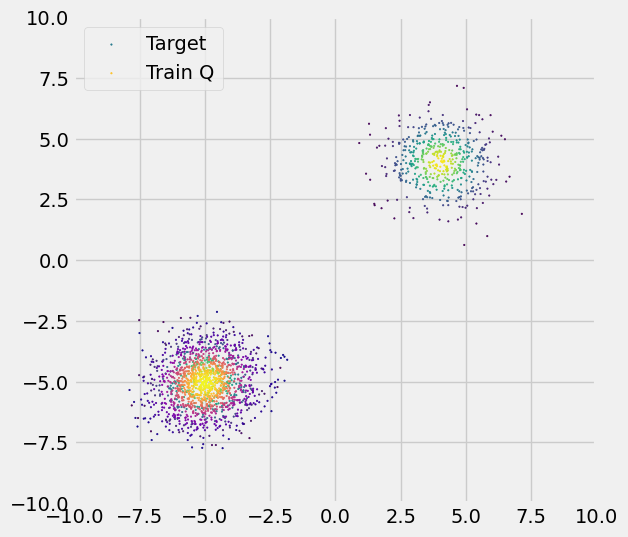

In [20]:
# Initialize parameters:
train_mu, raw_l11, raw_l21, raw_l22 = get_parameters(mu=-2., sigma=1.)

# Put them all in an optimizer
optimizer = torch.optim.Adam([train_mu, raw_l11, raw_l21, raw_l22], lr=0.1)

# Training loop
for i in range(5000):
    optimizer.zero_grad()
    
    # Build Q from current parameters
    Q = create_distr(train_mu, raw_l11, raw_l21, raw_l22)
    
    # Compute JS or KL
    loss = js_div(target, Q, num_samples=5000)
    
    loss.backward()
    optimizer.step()
    
    if i % 100 == 0:
        clear_output(True)
        print(f"Step {i}, JS loss = {loss.item():.4f}")
        print("mu =", train_mu.data)
        print("raw_l11 =", raw_l11.data, "raw_l21 =", raw_l21.data, "raw_l22 =", raw_l22.data)
        
        # Visualization
        plt.figure(figsize=(6,6))
        x_samps = target.sample((1000,))
        px = target.log_prob(x_samps).exp()
        plot_2d_dots(x_samps, color=px.detach(), label='Target')

        q_samps = Q.sample((1000,))
        qx = Q.log_prob(q_samps).exp().detach()
        plot_2d_dots(q_samps, color=qx, label='Train Q', cmap='plasma')
        plt.legend()
        plt.show()

## 4. MSE-Based Distance on Probabilities
[Described here](https://www.arxiv-vanity.com/papers/1611.04076/):

$$
\text{LSE\_loss} = \text{MSE}(q(x), p(x))
$$

Minimizing the L2 difference between probability densities can have unique behaviors. Let's explore how it looks.

In [21]:
def LSE_loss(qx, px):
    """
    Mean Square Error between px and qx.
    """
    return torch.nn.MSELoss()(qx, px)

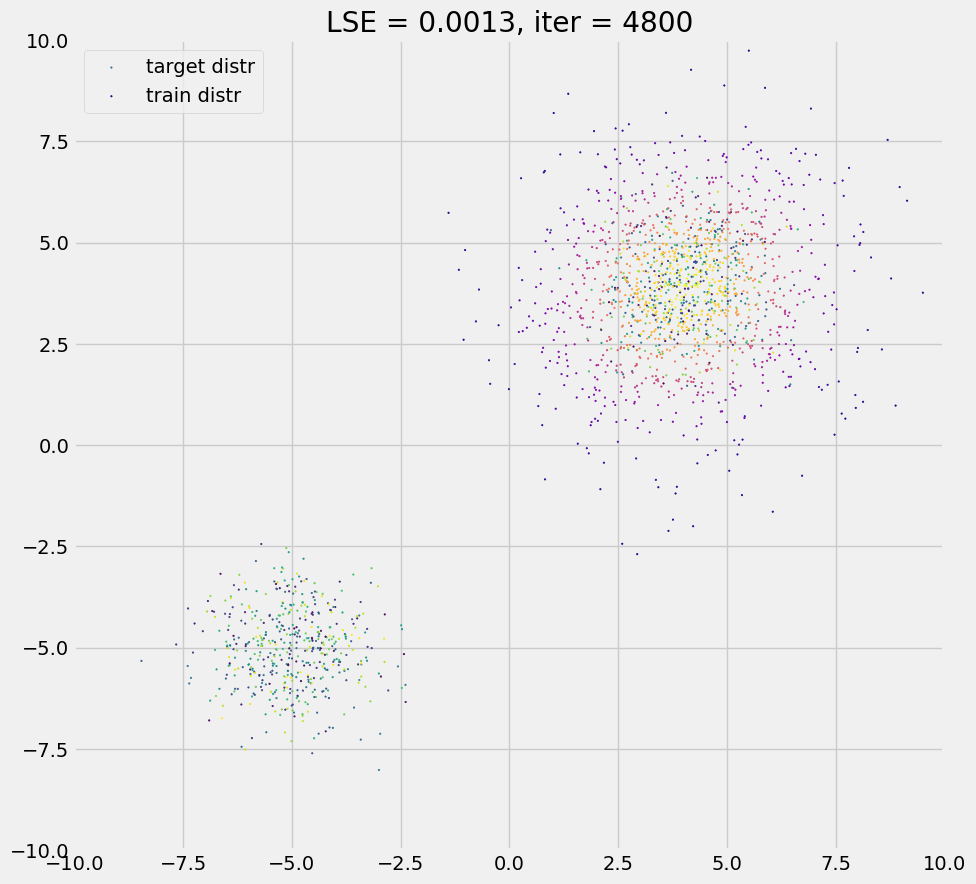

In [22]:
train_mu, raw_l11, raw_l21, raw_l22 = get_parameters(1, 1)
optimizer = torch.optim.Adam([train_mu, raw_l11, raw_l21, raw_l22], lr=0.001)

x = target.sample((1000,))

for i in range(5000):
    optimizer.zero_grad()
    Q = create_distr(train_mu, raw_l11, raw_l21, raw_l22)
    qx = Q.log_prob(x).exp()
    loss = LSE_loss(qx, px)
    loss.backward()
    optimizer.step()
    
    if i % 200 == 0:
        clear_output(True)
        plt.figure(figsize=(10, 10))
        plt.title(f'LSE = {loss.item():.4f}, iter = {i}')
        plot_2d_dots(x, color=px, label='target distr')
        q_sample = sample(Q, 1000)
        plot_2d_dots(q_sample, color=Q.log_prob(q_sample).exp().detach(), label='train distr', cmap='plasma')
        plt.legend()
        plt.show()

## 1D Example and Gradient Flow Visualization

### 1D Example

We'll use a simpler 1D scenario to visualize how gradients behave for KL vs. JS in a mixture setup.

$$
P(x) = \frac{1}{2} \mathcal{N}(\mu_1, \sigma_1) + \frac{1}{2} \mathcal{N}(\mu_2, \sigma_2)
$$

In [23]:
def get_parameters_1d(mu=0., sigma=1., requires_grad=True):
    """
    Creates trainable parameters for a 1D Gaussian:
      - Mean (mu)
      - Log of standard deviation (log_std)
    
    Args:
        mu (float): initial mean.
        sigma (float): initial standard deviation (must be >0).
        requires_grad (bool): if the parameters should require gradients.
    
    Returns:
        train_mu: torch.Tensor, shape (1,)
        log_std: torch.Tensor, shape (1,)
    """
    train_mu = torch.tensor([mu], dtype=torch.float32, requires_grad=requires_grad)
    log_std = torch.tensor([np.log(sigma)], dtype=torch.float32, requires_grad=requires_grad)
    return train_mu, log_std

def create_distr_1d(mu, log_std):
    """
    Constructs a 1D Normal distribution using the Cholesky (log std) parameterization.
    
    Args:
        mu: mean (torch.Tensor of shape (1,))
        log_std: log(std) (torch.Tensor of shape (1,))
    
    Returns:
        A torch.distributions.Normal representing Q.
    """
    std = torch.exp(log_std)
    return distrs.Normal(mu, std)

In [24]:
# Define a target 1D mixture of two Gaussians
mu1, log_std1 = get_parameters_1d(-3, 0.5, requires_grad=False)
mu2, log_std2 = get_parameters_1d(-8, 0.5, requires_grad=False)

target1_1d = create_distr_1d(mu1, log_std1)
target2_1d = create_distr_1d(mu2, log_std2)

def sample_from_mixture1d(n_samples):
    half = n_samples // 2
    x1 = target1_1d.sample((half,))
    x2 = target2_1d.sample((n_samples - half,))
    return torch.cat([x1, x2], dim=0)

def log_prob_mixture1d(x):
    log_p1 = target1_1d.log_prob(x)
    log_p2 = target2_1d.log_prob(x)
    half_log = np.log(0.5)
    return torch.logaddexp(log_p1 + half_log, log_p2 + half_log)

class MixtureTarget1D:
    def sample(self, shape=torch.Size([])):
        if len(shape) == 0:
            shape = (1,)
        n = shape[0]
        return sample_from_mixture1d(n)
    
    def log_prob(self, x):
        return log_prob_mixture1d(x)

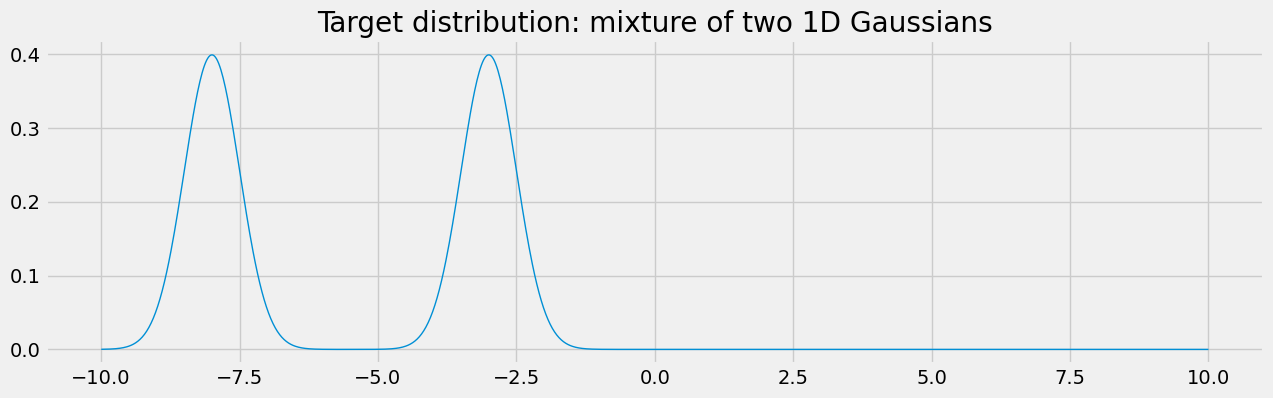

In [25]:
# Create an instance of the 1D mixture target:
target_1d = MixtureTarget1D()

# Plot target density for visualization:
x_1d = torch.linspace(-10, 10, 1000)
px_1d = target_1d.log_prob(x_1d).exp()

plt.figure(figsize=(14,4))
plt.plot(x_1d.numpy(), px_1d.numpy(), linewidth=1)
plt.title("Target distribution: mixture of two 1D Gaussians")
plt.show()

### KL Loss in 1D

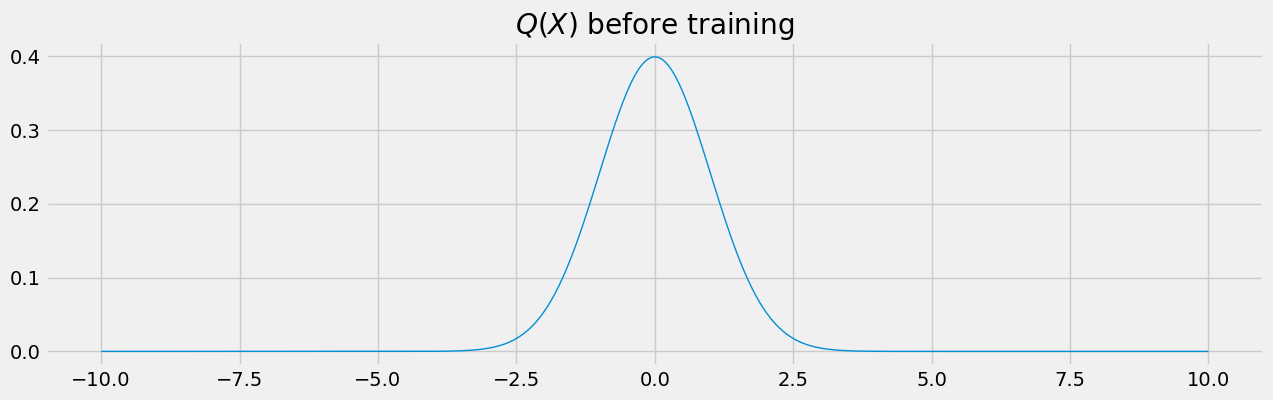

In [31]:
# We'll try fitting Q, a single 1D Gaussian
train_mu_1d, train_log_std_1d = get_parameters_1d(0, 1)
Q_1d = create_distr_1d(train_mu_1d, train_log_std_1d)

# Visualize initial Q
plt.figure(figsize=(14,4))
qx_1d = Q_1d.log_prob(x_1d).exp()
plt.plot(x_1d.numpy(), qx_1d.detach().numpy(), linewidth=1)
plt.title('$Q(X)$ before training')
plt.show()

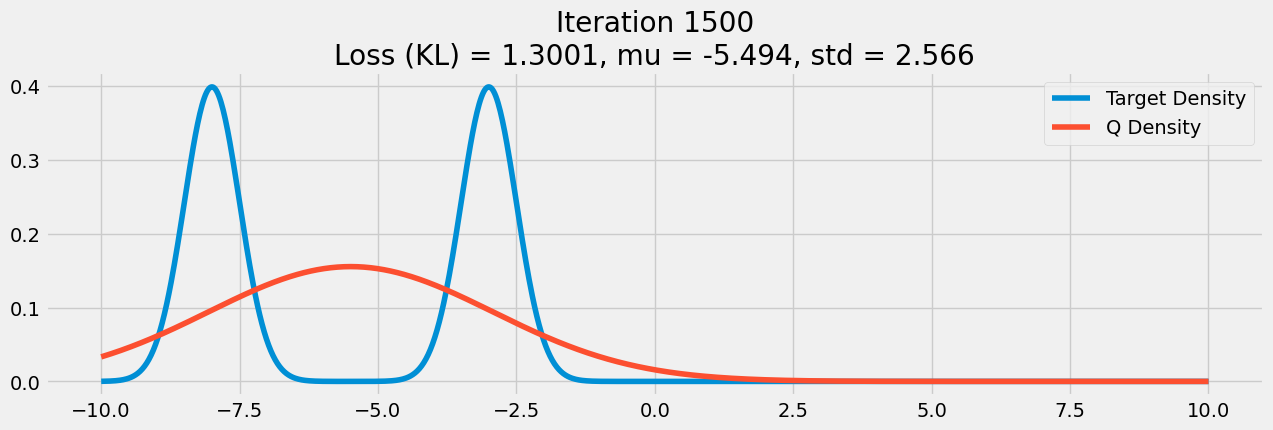

In [33]:
optimizer = torch.optim.Adam([train_mu_1d, train_log_std_1d], lr=0.01)
grads_mu = []
grads_log_std = []

num_iterations = 2000
# For the KL loss, we use a batch of samples from the target:
target_samples = target_1d.sample((1000,))
p_target = target_1d.log_prob(target_samples).exp()

for i in range(num_iterations):
    optimizer.zero_grad()
    
    Q_1d = create_distr_1d(train_mu_1d, train_log_std_1d)
    q_target = Q_1d.log_prob(target_samples).exp()
    
    loss_kl = kl_loss(p_target, q_target)
    loss_kl.backward()
    
    grads_mu.append(abs(train_mu_1d.grad.item()))
    grads_log_std.append(abs(train_log_std_1d.grad.item()))
    
    optimizer.step()
    
    if i % 500 == 0:
        clear_output(True)
        Q_1d = create_distr_1d(train_mu_1d, train_log_std_1d)
        qx_1d = Q_1d.log_prob(x_1d).exp()
        plt.figure(figsize=(14,4))
        plt.title(f"Iteration {i}\nLoss (KL) = {loss_kl.item():.4f}, mu = {train_mu_1d.item():.3f}, std = {torch.exp(train_log_std_1d).item():.3f}")
        plt.plot(x_1d.numpy(), px_1d.numpy(), label='Target Density')
        plt.plot(x_1d.numpy(), qx_1d.detach().numpy(), label='Q Density')
        plt.legend()
        plt.show()

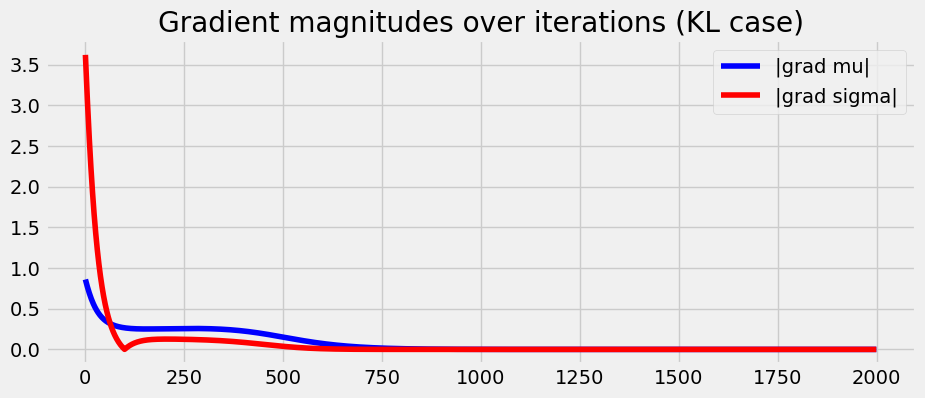

In [34]:
plt.figure(figsize=(10,4))
plt.plot(grads_mu, c='blue', label='|grad mu|')
plt.plot(grads_log_std, c='red', label='|grad sigma|')
plt.title("Gradient magnitudes over iterations (KL case)")
plt.legend()
plt.show()

### JS Loss in 1D

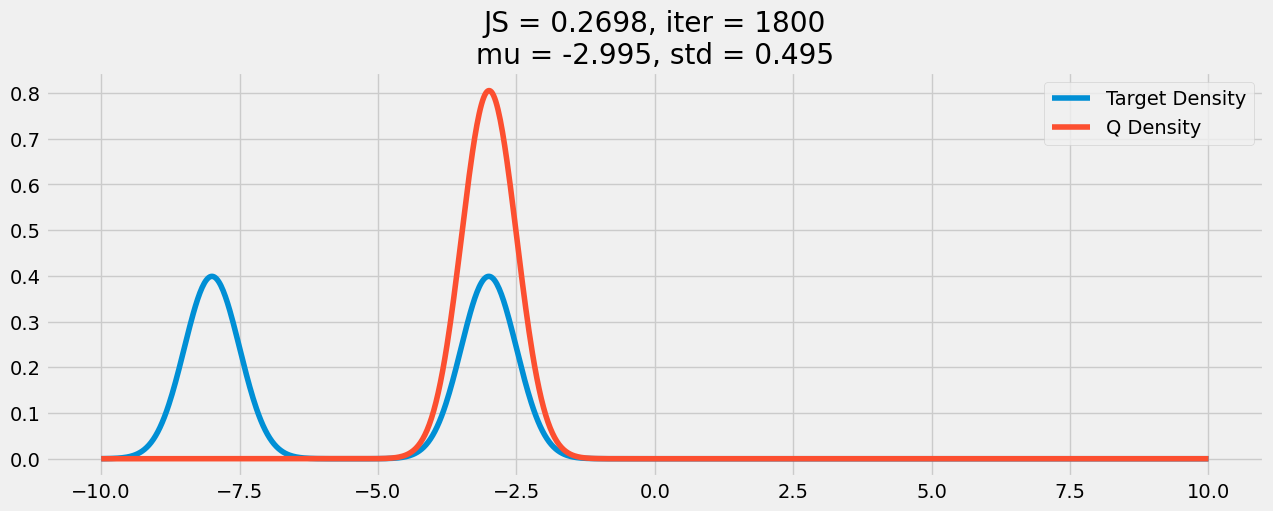

In [35]:
# Initialize Q
train_mu_1d, log_std_1d = get_parameters_1d(mu=0., sigma=1.)
optimizer = torch.optim.SGD([train_mu_1d, log_std_1d], lr=0.1)

grads_mu = []
grads_log_std = []

num_iterations = 2000

for i in range(num_iterations):
    optimizer.zero_grad()
    
    Q_1d = create_distr_1d(train_mu_1d, log_std_1d)
    loss_js = js_div(target_1d, Q_1d, num_samples=5000)
    loss_js.backward()
    
    grads_mu.append(abs(train_mu_1d.grad.item()))
    grads_log_std.append(abs(log_std_1d.grad.item()))
    
    optimizer.step()
    
    if i % 300 == 0:
        clear_output(True)
        Q_1d = create_distr_1d(train_mu_1d, log_std_1d)
        qx_1d = Q_1d.log_prob(x_1d).exp()
        plt.figure(figsize=(14, 5))
        plt.title(f"JS = {loss_js.item():.4f}, iter = {i}\n"
                  f"mu = {train_mu_1d.item():.3f}, std = {torch.exp(log_std_1d).item():.3f}")
        plt.plot(x_1d.numpy(), px_1d.numpy(), label='Target Density')
        plt.plot(x_1d.numpy(), qx_1d.detach().numpy(), label='Q Density')
        plt.legend()
        plt.show()

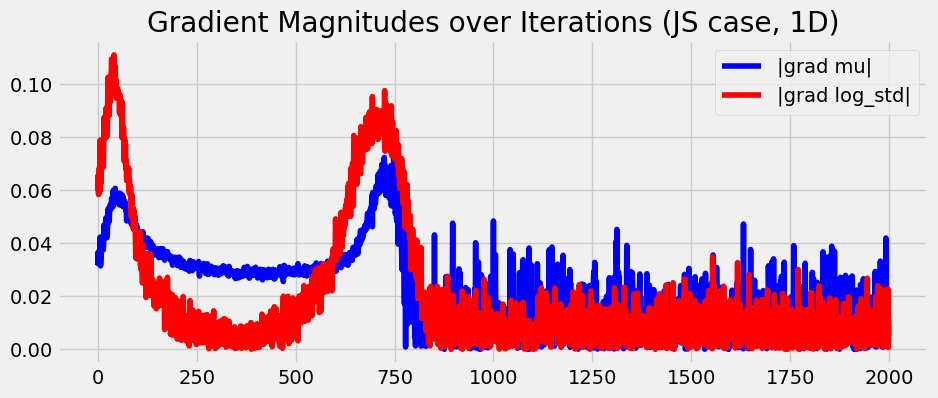

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(grads_mu, c='blue', label='|grad mu|')
plt.plot(grads_log_std, c='red', label='|grad log_std|')
plt.title("Gradient Magnitudes over Iterations (JS case, 1D)")
plt.legend()
plt.show()